# Taller 3: Exploratory Data Analysis (EDA) y Data Wrangling

## Introducción

Este notebook sigue un enfoque de **respuesta directa + soporte**. En cada bloque primero delimito qué voy a evaluar, luego muestro la evidencia tabular o gráfica mínima necesaria, después justifico la decisión estadística y cierro con una conclusión que responde explícitamente la consigna.

El objetivo no es solo describir el dataset, sino **construir confianza analítica** antes de responder preguntas de negocio. Por eso documento las cuatro dimensiones de calidad de datos que sí cambian el análisis posterior: **precisión, completitud, consistencia y sensibilidad**. Cuando tomo una decisión de limpieza, también explico qué alternativa descarté y qué sesgo habría introducido.
    


## Diccionario de Datos

Hay cinco tablas en el conjunto de datos que deberás usar en conjunto:

- `instacart_orders.csv`: cada fila es un pedido en la app de Instacart
    - `'order_id'`: ID que identifica de manera única cada pedido
    - `'user_id'`: ID que identifica de manera única a cada cliente
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 es domingo)
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido
    - `'days_since_prior_order'`: número de días desde que este cliente hizo su último pedido
- `products.csv`: cada fila corresponde a un producto
    - `'product_id'`: ID único del producto
    - `'product_name'`: nombre del producto
    - `'aisle_id'`: ID único de la categoría del pasillo
    - `'department_id'`: ID único de la categoría del departamento
- `order_products.csv`: cada fila corresponde a un artículo en un pedido
    - `'order_id'`: ID único del pedido
    - `'product_id'`: ID único del producto
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo al carrito
    - `'reordered'`: 0 si el cliente no había pedido este producto antes, 1 si ya lo había hecho
- `aisles.csv`
    - `'aisle_id'`: ID único del pasillo
    - `'aisle'`: nombre del pasillo
- `departments.csv`
    - `'department_id'`: ID único del departamento
    - `'department'`: nombre del departamento

# Paso 1: Exploración Inicial

Antes de limpiar o modelar, necesito responder una pregunta básica: **¿qué tengo exactamente entre manos?** La exploración inicial se centra en cuatro frentes: tamaño de cada tabla, tipos computacionales, primera evidencia de valores ausentes/duplicados y una muestra aleatoria que evite el sesgo de inspeccionar solo las primeras filas.

Como este dataset es relacional, también voy a fijar desde el inicio la **granularidad** de cada fuente. Esa decisión es clave porque muchas preguntas del taller deben responderse a nivel de orden, no a nivel de línea de producto.
    


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 25)
RANDOM_STATE = 42

# Lectura de las tablas fuente
orders = pd.read_csv('datos/instacart_orders.csv', sep=';')
products = pd.read_csv('datos/products.csv', sep=';')
order_products = pd.read_csv('datos/order_products.csv', sep=';')
aisles = pd.read_csv('datos/aisles.csv', sep=';')
departments = pd.read_csv('datos/departments.csv', sep=';')

tables = {
    'orders': orders,
    'products': products,
    'order_products': order_products,
    'aisles': aisles,
    'departments': departments,
}
    


## 1.1 Radiografía estructural

Se analizó una muestra aleatoria siempe con el objetivo de verificar si el tipo de la variable coincide con el rol estadístico esperado y detectar problemas de completitud o precisión.
    


In [18]:
for name, df in tables.items():
    print(f'\n===== {name.upper()} =====')
    print('Primeras filas:')
    print(df.head(3).to_string(index=False))
    print('\nEstructura (info):')
    df.info()
    print('\nMuestra aleatoria simple:')
    print(df.sample(5, random_state=RANDOM_STATE).to_string(index=False))
    print('-' * 100)
    



===== ORDERS =====
Primeras filas:
 order_id  user_id  order_number  order_dow  order_hour_of_day  days_since_prior_order
  1515936   183418            11          6                 13                    30.0
  1690866   163593             5          5                 12                     9.0
  1454967    39980             4          5                 19                     2.0

Estructura (info):
<class 'pandas.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB

Muestra aleat

In [19]:
primary_keys = {
    'orders': 'order_id',
    'products': 'product_id',
    'aisles': 'aisle_id',
    'departments': 'department_id',
}

quality_summary = []
for name, df in tables.items():
    row = {
        'table': name,
        'rows': df.shape[0],
        'columns': df.shape[1],
        'missing_rows': int(df.isna().any(axis=1).sum()),
        'missing_cells': int(df.isna().sum().sum()),
        'duplicated_rows': int(df.duplicated().sum()),
    }
    pk = primary_keys.get(name)
    row['duplicated_primary_key'] = int(df[pk].duplicated().sum()) if pk else np.nan
    quality_summary.append(row)

quality_summary = pd.DataFrame(quality_summary).sort_values('rows', ascending=False)
print(quality_summary.to_string(index=False))
    


         table    rows  columns  missing_rows  missing_cells  duplicated_rows  duplicated_primary_key
order_products 4545007        4           836            836                0                     NaN
        orders  478967        6         28819          28819               15                    15.0
      products   49694        4          1258           1258                0                     0.0
        aisles     134        2             0              0                0                     0.0
   departments      21        2             0              0                0                     0.0


In [20]:
role_check = pd.DataFrame([
    {'tabla': 'orders', 'variable': 'order_id', 'rol_estadistico': 'Identificador nominal', 'dtype': str(orders['order_id'].dtype)},
    {'tabla': 'orders', 'variable': 'user_id', 'rol_estadistico': 'Identificador nominal', 'dtype': str(orders['user_id'].dtype)},
    {'tabla': 'orders', 'variable': 'order_dow', 'rol_estadistico': 'Temporal discreta (0-6)', 'dtype': str(orders['order_dow'].dtype)},
    {'tabla': 'orders', 'variable': 'order_hour_of_day', 'rol_estadistico': 'Temporal discreta (0-23)', 'dtype': str(orders['order_hour_of_day'].dtype)},
    {'tabla': 'orders', 'variable': 'days_since_prior_order', 'rol_estadistico': 'Cuantitativa discreta acotada', 'dtype': str(orders['days_since_prior_order'].dtype)},
    {'tabla': 'products', 'variable': 'product_id', 'rol_estadistico': 'Identificador nominal', 'dtype': str(products['product_id'].dtype)},
    {'tabla': 'products', 'variable': 'product_name', 'rol_estadistico': 'Categórica nominal', 'dtype': str(products['product_name'].dtype)},
    {'tabla': 'order_products', 'variable': 'add_to_cart_order', 'rol_estadistico': 'Ordinal discreta', 'dtype': str(order_products['add_to_cart_order'].dtype)},
    {'tabla': 'order_products', 'variable': 'reordered', 'rol_estadistico': 'Binaria', 'dtype': str(order_products['reordered'].dtype)},
])
print(role_check.to_string(index=False))
    


         tabla               variable               rol_estadistico   dtype
        orders               order_id         Identificador nominal   int64
        orders                user_id         Identificador nominal   int64
        orders              order_dow       Temporal discreta (0-6)   int64
        orders      order_hour_of_day      Temporal discreta (0-23)   int64
        orders days_since_prior_order Cuantitativa discreta acotada float64
      products             product_id         Identificador nominal   int64
      products           product_name            Categórica nominal     str
order_products      add_to_cart_order              Ordinal discreta float64
order_products              reordered                       Binaria   int64


### Hallazgos iniciales

**Respuesta directa:** la estructura general del dataset esta correcta y relacionalmente coherente, sin embargo:

- **`orders`** tiene granularidad correcta a nivel de orden. Los dominios de `order_dow` y `order_hour_of_day` parecen lógicos, pero `days_since_prior_order` sale como `float64` porque hay valores ausentes que requieren explicación causal.
- **`products`** mantiene integridad en `product_id`, pero `product_name` tiene ausencias. Eso no es grave por volumen, pero sí por semántica: si el catálogo falla, luego fallan las interpretaciones de top productos y canastas.
- **`order_products`** tiene la granularidad más fina del sistema: producto dentro de orden. Aquí `reordered` ya luce binaria, mientras que `add_to_cart_order` debería ser entera/ordinal y no flotante; eso anticipa faltantes en una variable que conceptualmente no debería perderse.
- **`aisles`** y **`departments`** son tablas pequeñas y limpias, útiles como dimensiones de referencia.

Resultado: **duplicados en `orders`**, **ausencias estructurales o no aleatorias en tres columnas clave** y **verificación de consistencia entre tipo estadístico y dtype computacional**.
    


# Paso 2: Auditoría de Calidad de Datos
    


## 2.1 Precisión: duplicados explícitos e implícitos

Se revisará precisión en dos niveles. Primero, duplicados exactos en `orders`, porque inflan conteos y alteran cualquier análisis temporal. Segundo, duplicados implícitos en `products`, donde el problema no es la llave primaria sino la estandarización del nombre descriptivo.
    


In [21]:
orders_exact_duplicates = orders[orders.duplicated(keep=False)].sort_values(list(orders.columns))
wed_2am_orders = orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)]

precision_orders_summary = pd.DataFrame([
    {'metrica': 'Filas totales en orders', 'valor': len(orders)},
    {'metrica': 'Filas duplicadas exactas a eliminar', 'valor': int(orders.duplicated().sum())},
    {'metrica': 'Filas involucradas al incluir originales', 'valor': len(orders_exact_duplicates)},
    {'metrica': 'Filas totales del miércoles 2 AM', 'valor': len(wed_2am_orders)},
    {'metrica': 'Filas duplicadas dentro del miércoles 2 AM', 'valor': int(wed_2am_orders.duplicated(keep=False).sum())},
    {'metrica': 'Filas no duplicadas en miércoles 2 AM', 'valor': int(len(wed_2am_orders) - wed_2am_orders.duplicated(keep=False).sum())},
])
print(precision_orders_summary.to_string(index=False))

if not orders_exact_duplicates.empty:
    print('\nEjemplo de duplicados exactos en orders:')
    print(orders_exact_duplicates.head(10).to_string(index=False))
    print('\nAgrupación de duplicados por día y hora:')
    print(orders_exact_duplicates.groupby(['order_dow', 'order_hour_of_day']).size().to_string())

orders_clean = orders.drop_duplicates().copy()
print(f'\nFilas en orders después de deduplicar: {len(orders_clean):,}')
    


                                   metrica  valor
                   Filas totales en orders 478967
       Filas duplicadas exactas a eliminar     15
  Filas involucradas al incluir originales     30
          Filas totales del miércoles 2 AM    121
Filas duplicadas dentro del miércoles 2 AM     30
     Filas no duplicadas en miércoles 2 AM     91

Ejemplo de duplicados exactos en orders:
 order_id  user_id  order_number  order_dow  order_hour_of_day  days_since_prior_order
   391768    57671            19          3                  2                    10.0
   391768    57671            19          3                  2                    10.0
   408114    68324             4          3                  2                    18.0
   408114    68324             4          3                  2                    18.0
   467134    63189            21          3                  2                     2.0
   467134    63189            21          3                  2                     2.0

In [22]:
products_name_audit = products.copy()
products_name_audit['product_name_lower'] = products_name_audit['product_name'].str.lower()

duplicate_name_rows = products_name_audit[
    products_name_audit['product_name_lower'].notna()
    & products_name_audit.duplicated(subset=['product_name_lower'], keep=False)
].sort_values(['product_name_lower', 'product_id'])

precision_products_summary = pd.DataFrame([
    {'metrica': 'Duplicados exactos en products', 'valor': int(products.duplicated().sum())},
    {'metrica': 'Duplicados por product_id', 'valor': int(products['product_id'].duplicated().sum())},
    {'metrica': 'Filas con nombre repetido ignorando mayúsculas', 'valor': len(duplicate_name_rows)},
    {'metrica': 'Nombres únicos repetidos ignorando mayúsculas', 'valor': int(duplicate_name_rows['product_name_lower'].nunique())},
])
print(precision_products_summary.to_string(index=False))
print('\nEjemplos de duplicados implícitos por nombre:')
print(duplicate_name_rows[['product_id', 'product_name', 'aisle_id', 'department_id']].head(20).to_string(index=False))
    


                                       metrica  valor
                Duplicados exactos en products      0
                     Duplicados por product_id      0
Filas con nombre repetido ignorando mayúsculas    207
 Nombres únicos repetidos ignorando mayúsculas    103

Ejemplos de duplicados implícitos por nombre:
 product_id                              product_name  aisle_id  department_id
      23340 18-in-1 Hemp Peppermint Pure-Castile Soap        25             11
      31845 18-In-1 Hemp Peppermint Pure-Castile Soap        25             11
      13153           Aged Balsamic Vinegar of Modena        19             13
      19942           Aged Balsamic Vinegar Of Modena        19             13
      22583        Albacore Solid White Tuna In Water        95             15
      24831        Albacore Solid White Tuna in Water        95             15
        516                    American Cheese Slices        21             16
       9038                    American Cheese slic

### Conclusiones sobre la precisión

Hay un problema real de precisión en `orders`, y se corrigió eliminando duplicados exactos; en `products`, en cambio, el problema es de normalización textual, no de identidad de entidad.

- En `orders` se detectaron **15 filas duplicadas exactas**, equivalentes a **30 registros al contar sus originales**, todos concentrados en **miércoles a las 2:00 AM**. Eso sugiere un patrón de reingesta o duplicación operativa en una ventana horaria específica, no un comportamiento genuino del negocio. Por esa razón la decisión correcta es **eliminar esas filas**.
- En `products` no existen duplicados por `product_id`, por lo que la llave primaria del catálogo se conserva. Sí aparecen **207 filas asociadas a 103 nombres repetidos** si se ignoran mayúsculas/minúsculas. Aquí **no corresponde consolidar automáticamente**, porque el identificador analítico confiable sigue siendo `product_id`; lo que falla es la estandarización del atributo textual.    


## 2.2 Completitud: tratamiento de valores ausentes

Análisis de valores ausentes con el marco de Rubin: **MCAR, MAR o MNAR**. 
En este dataset hay tres casos críticos y conceptualmente diferentes: un faltante de catálogo (`product_name`), un faltante estructural de primera compra (`days_since_prior_order`) y una pérdida técnica de posición en carrito (`add_to_cart_order`).


In [23]:
missing_by_table = pd.DataFrame([
    {
        'table': name,
        'rows': df.shape[0],
        'missing_rows': int(df.isna().any(axis=1).sum()),
        'missing_cells': int(df.isna().sum().sum()),
        'missing_rate_rows_pct': round(df.isna().any(axis=1).mean() * 100, 4),
    }
    for name, df in tables.items()
]).sort_values('missing_cells', ascending=False)

missing_by_column_records = []
for name, df in tables.items():
    for column in df.columns:
        missing_n = int(df[column].isna().sum())
        if missing_n > 0:
            missing_by_column_records.append({
                'table': name,
                'column': column,
                'missing_n': missing_n,
                'missing_pct': round(missing_n / len(df) * 100, 4),
            })
missing_by_column = pd.DataFrame(missing_by_column_records).sort_values(['missing_pct', 'missing_n'], ascending=[False, False])

print('Resumen de faltantes por tabla:')
print(missing_by_table.to_string(index=False))
print('\nResumen de faltantes por columna:')
print(missing_by_column.to_string(index=False))
    


Resumen de faltantes por tabla:
         table    rows  missing_rows  missing_cells  missing_rate_rows_pct
        orders  478967         28819          28819                 6.0169
      products   49694          1258           1258                 2.5315
order_products 4545007           836            836                 0.0184
        aisles     134             0              0                 0.0000
   departments      21             0              0                 0.0000

Resumen de faltantes por columna:
         table                 column  missing_n  missing_pct
        orders days_since_prior_order      28819       6.0169
      products           product_name       1258       2.5315
order_products      add_to_cart_order        836       0.0184


### Caso 1: `product_name`

**Pregunta analítica:** ¿los nombres de producto faltan de forma aleatoria o están concentrados en una zona concreta del catálogo?

- **`product_name`** tiene **1,258 ausencias (2.53% del catálogo)** y el patrón está completamente concentrado en `aisle = missing` y `department = missing`. Esto descarta MCAR y apunta a una **ausencia estructurada de catálogo**, más cercana a **MAR** que a un error aleatorio. Se creó `product_name_missing` y se imputó `Unknown` para no perder filas ni ocultar el problema.


In [24]:
products_missing_names = (
    products[products['product_name'].isna()]
    .merge(aisles, on='aisle_id', how='left')
    .merge(departments, on='department_id', how='left')
)

product_name_pattern = pd.DataFrame([
    {'metrica': 'Productos con nombre ausente', 'valor': len(products_missing_names)},
    {'metrica': '% del catálogo afectado', 'valor': round(len(products_missing_names) / len(products) * 100, 4)},
    {'metrica': 'Aisles distintos entre faltantes', 'valor': products_missing_names['aisle'].nunique()},
    {'metrica': 'Departments distintos entre faltantes', 'valor': products_missing_names['department'].nunique()},
])

print(product_name_pattern.to_string(index=False))
print('\nDistribución de faltantes de product_name por aisle/department:')
print(products_missing_names.groupby(['aisle', 'department']).size().to_string())
print('\nMuestra de productos sin nombre:')
print(products_missing_names[['product_id', 'aisle_id', 'aisle', 'department_id', 'department']].head(10).to_string(index=False))
    


                              metrica     valor
         Productos con nombre ausente 1258.0000
              % del catálogo afectado    2.5315
     Aisles distintos entre faltantes    1.0000
Departments distintos entre faltantes    1.0000

Distribución de faltantes de product_name por aisle/department:
aisle    department
missing  missing       1258

Muestra de productos sin nombre:
 product_id  aisle_id   aisle  department_id department
         38       100 missing             21    missing
         72       100 missing             21    missing
        110       100 missing             21    missing
        297       100 missing             21    missing
        417       100 missing             21    missing
        437       100 missing             21    missing
        440       100 missing             21    missing
        472       100 missing             21    missing
        491       100 missing             21    missing
        556       100 missing             21    missi

### Caso 2: `days_since_prior_order`

**Pregunta analítica:** ¿la ausencia se explica porque el usuario está haciendo su primera compra o se distribuye también entre órdenes recurrentes?

**`days_since_prior_order`** presenta **28,817 ausencias en la tabla depurada (6.02% de órdenes)**. La evidencia es perfecta: **todos los faltantes son primeras órdenes y todas las primeras órdenes carecen de ese valor**. Aquí imputar media o mediana sería conceptualmente incorrecto, porque fabricaría un tiempo transcurrido que no existe. Por eso se creó `first_order_flag` y se usó `-1`.


In [25]:
orders_missing_days = orders_clean[orders_clean['days_since_prior_order'].isna()].copy()

first_order_crosstab = pd.crosstab(
    orders_clean['order_number'].eq(1).map({True: 'Primera orden', False: 'Orden recurrente'}),
    orders_clean['days_since_prior_order'].isna().map({True: 'days_since_prior_order ausente', False: 'days_since_prior_order presente'}),
)

missing_days_summary = pd.DataFrame([
    {'metrica': 'Órdenes con days_since_prior_order ausente', 'valor': len(orders_missing_days)},
    {'metrica': '% de orders_clean afectado', 'valor': round(len(orders_missing_days) / len(orders_clean) * 100, 4)},
    {'metrica': 'Todos los faltantes ocurren en order_number = 1', 'valor': bool(orders_missing_days['order_number'].eq(1).all())},
    {'metrica': 'Todas las primeras órdenes tienen este faltante', 'valor': bool(orders_clean.loc[orders_clean['order_number'] == 1, 'days_since_prior_order'].isna().all())},
])

print(missing_days_summary.to_string(index=False))
print('\nTabla de contingencia:')
print(first_order_crosstab.to_string())
print('\nEjemplo de órdenes con days_since_prior_order ausente:')
print(orders_missing_days.head(10).to_string(index=False))
    


                                        metrica   valor
     Órdenes con days_since_prior_order ausente   28817
                     % de orders_clean afectado  6.0167
Todos los faltantes ocurren en order_number = 1    True
Todas las primeras órdenes tienen este faltante    True

Tabla de contingencia:
days_since_prior_order  days_since_prior_order ausente  days_since_prior_order presente
order_number                                                                           
Orden recurrente                                     0                           450135
Primera orden                                    28817                                0

Ejemplo de órdenes con days_since_prior_order ausente:
 order_id  user_id  order_number  order_dow  order_hour_of_day  days_since_prior_order
   133707   182261             1          3                 10                     NaN
   787445    25685             1          6                 18                     NaN
   294410   111449         

### Caso 3: `add_to_cart_order`

**Pregunta analítica:** ¿la posición en carrito se pierde al azar o aparece asociada al tamaño de la orden?

**`add_to_cart_order`** tiene **836 faltantes**, pero distribuidos en apenas **70 órdenes (0.0156% de las órdenes)**. El patrón tampoco es aleatorio: **todas** las órdenes afectadas superan los **64 productos**, y **todas** las órdenes de más de 64 productos presentan el faltante. Eso es evidencia fuerte de **truncamiento operativo del sistema**, no de ruido aleatorio. Se preservó con `add_to_cart_order_missing` y se imputó `999` para no inventar una secuencia ordinal inexistente.


In [26]:
order_level_cart_audit = pd.DataFrame({
    'order_size': order_products.groupby('order_id').size(),
    'has_missing_cart_position': order_products.groupby('order_id')['add_to_cart_order'].apply(lambda s: s.isna().any()),
}).reset_index()
order_level_cart_audit['order_size_gt_64'] = order_level_cart_audit['order_size'] > 64

affected_orders = order_level_cart_audit[order_level_cart_audit['has_missing_cart_position']].copy()
cart_position_crosstab = pd.crosstab(order_level_cart_audit['order_size_gt_64'], order_level_cart_audit['has_missing_cart_position'])

cart_missing_summary = pd.DataFrame([
    {'metrica': 'Líneas con add_to_cart_order ausente', 'valor': int(order_products['add_to_cart_order'].isna().sum())},
    {'metrica': '% de líneas afectadas', 'valor': round(order_products['add_to_cart_order'].isna().mean() * 100, 4)},
    {'metrica': 'Órdenes afectadas', 'valor': len(affected_orders)},
    {'metrica': '% de órdenes afectadas', 'valor': round(len(affected_orders) / order_products['order_id'].nunique() * 100, 4)},
    {'metrica': 'Todas las órdenes afectadas tienen más de 64 ítems', 'valor': bool(affected_orders['order_size_gt_64'].all())},
])

print(cart_missing_summary.to_string(index=False))
print('\nDistribución del tamaño de las órdenes afectadas:')
print(affected_orders['order_size'].describe().to_string())
print('\nTabla de contingencia (orden grande vs faltante de posición):')
print(cart_position_crosstab.to_string())
print('\nMuestra de órdenes afectadas:')
print(affected_orders.head(10).to_string(index=False))
    


                                           metrica   valor
              Líneas con add_to_cart_order ausente     836
                             % de líneas afectadas  0.0184
                                 Órdenes afectadas      70
                            % de órdenes afectadas  0.0156
Todas las órdenes afectadas tienen más de 64 ítems    True

Distribución del tamaño de las órdenes afectadas:
count     70.000000
mean      75.942857
std       12.898585
min       65.000000
25%       67.000000
50%       71.000000
75%       78.000000
max      127.000000

Tabla de contingencia (orden grande vs faltante de posición):
has_missing_cart_position   False  True 
order_size_gt_64                        
False                      449976      0
True                            0     70

Muestra de órdenes afectadas:
 order_id  order_size  has_missing_cart_position  order_size_gt_64
     9310          65                       True              True
    61355         127                      

## Estrategia de imputación — variables con valores faltantes

### `product_name`

**Mecanismo probable:** MAR / ausencia estructurada de catálogo

> **Evidencia:** 100% de los faltantes están en `aisle=missing` y `department=missing`.

| | |
|---|---|
| **Estrategia aplicada** | Crear flag `product_name_missing` + imputar `Unknown` |
| **Alternativa descartada** | Eliminar filas o imputar con moda textual |
| **Por qué se descarta** | Eliminar degrada el catálogo; imputar una moda oculta el problema semántico |

---

### `days_since_prior_order`

**Mecanismo probable:** Ausencia estructural / MAR condicionada a `order_number`

> **Evidencia:** Todos los faltantes son primeras órdenes y todas las primeras órdenes carecen de valor.

| | |
|---|---|
| **Estrategia aplicada** | Crear `first_order_flag` + imputar sentinel `-1` |
| **Alternativa descartada** | Media/mediana o eliminación de filas |
| **Por qué se descarta** | La media inventa un tiempo inexistente; eliminar sesga hacia usuarios recurrentes |

---

### `add_to_cart_order`

**Mecanismo probable:** No MCAR / truncamiento operativo por tamaño de orden

> **Evidencia:** 100% de las órdenes > 64 ítems presentan posiciones faltantes.

| | |
|---|---|
| **Estrategia aplicada** | Crear `add_to_cart_order_missing` + imputar sentinel `999` |
| **Alternativa descartada** | Media/mediana o secuenciar posiciones inventadas |
| **Por qué se descarta** | Alteraría una variable ordinal y fabricaría un orden de carrito no observado |

In [29]:
# Aplicación de las soluciones sobre copias limpias
products_clean = products.copy()
products_clean['product_name_missing'] = products_clean['product_name'].isna()
products_clean['product_name'] = products_clean['product_name'].fillna('Unknown')

orders_clean['first_order_flag'] = orders_clean['days_since_prior_order'].isna()
orders_clean['days_since_prior_order'] = orders_clean['days_since_prior_order'].fillna(-1)

order_products_clean = order_products.copy()
order_products_clean['add_to_cart_order_missing'] = order_products_clean['add_to_cart_order'].isna()
order_products_clean['add_to_cart_order'] = order_products_clean['add_to_cart_order'].fillna(999).astype(int)

In [30]:
post_missing_validation = pd.DataFrame([
    {'dataset': 'orders_clean', 'remaining_missing_cells': int(orders_clean.isna().sum().sum())},
    {'dataset': 'products_clean', 'remaining_missing_cells': int(products_clean.isna().sum().sum())},
    {'dataset': 'order_products_clean', 'remaining_missing_cells': int(order_products_clean.isna().sum().sum())},
])

flag_validation = pd.DataFrame([
    {'flag': 'product_name_missing', 'count': int(products_clean['product_name_missing'].sum()), 'interpretacion': 'Productos cuyo nombre venía ausente en origen'},
    {'flag': 'first_order_flag', 'count': int(orders_clean['first_order_flag'].sum()), 'interpretacion': 'Órdenes sin compra previa real'},
    {'flag': 'add_to_cart_order_missing', 'count': int(order_products_clean['add_to_cart_order_missing'].sum()), 'interpretacion': 'Líneas donde la posición del carrito no fue capturada'},
])

print('Validación posterior al tratamiento:')
print(post_missing_validation.to_string(index=False))
print('\nBanderas preservadas para no perder semántica:')
print(flag_validation.to_string(index=False))
    


Validación posterior al tratamiento:
             dataset  remaining_missing_cells
        orders_clean                        0
      products_clean                        0
order_products_clean                        0

Banderas preservadas para no perder semántica:
                     flag  count                                        interpretacion
     product_name_missing   1258         Productos cuyo nombre venía ausente en origen
         first_order_flag      0                        Órdenes sin compra previa real
add_to_cart_order_missing    836 Líneas donde la posición del carrito no fue capturada


### Conclusiones sobre la completitud

Los valores ausentes de este dataset **no son homogéneos**; cada uno responde a un mecanismo distinto y por eso necesitó un tratamiento diferente. La decisión correcta no era “rellenar todo”, sino preservar la semántica del faltante.

La validación final confirma que las copias limpias ya no tienen `NaN`, pero la información semántica del faltante **no se perdió** porque quedó almacenada en variables bandera.

## 2.3 Consistencia: dominios, tipos y coherencia relacional

La consistencia responde otra pregunta distinta: **aunque el dato exista, ¿está representado de forma correcta y dentro del dominio esperado?** 

In [31]:
consistency_checks = pd.DataFrame([
    {
        'chequeo': 'order_dow dentro de 0-6',
        'resultado': bool(orders_clean['order_dow'].between(0, 6).all()),
        'evidencia': f"mín={orders_clean['order_dow'].min()}, máx={orders_clean['order_dow'].max()}"
    },
    {
        'chequeo': 'order_hour_of_day dentro de 0-23',
        'resultado': bool(orders_clean['order_hour_of_day'].between(0, 23).all()),
        'evidencia': f"mín={orders_clean['order_hour_of_day'].min()}, máx={orders_clean['order_hour_of_day'].max()}"
    },
    {
        'chequeo': 'reordered es binaria',
        'resultado': set(order_products_clean['reordered'].unique()).issubset({0, 1}),
        'evidencia': f"valores={sorted(order_products_clean['reordered'].unique().tolist())}"
    },
    {
        'chequeo': 'order_id es único en orders_clean',
        'resultado': bool(orders_clean['order_id'].is_unique),
        'evidencia': f"duplicados por order_id={orders_clean['order_id'].duplicated().sum()}"
    },
    {
        'chequeo': 'product_id es único en products_clean',
        'resultado': bool(products_clean['product_id'].is_unique),
        'evidencia': f"duplicados por product_id={products_clean['product_id'].duplicated().sum()}"
    },
    {
        'chequeo': 'Todas las líneas de order_products enlazan a orders_clean',
        'resultado': bool(order_products_clean['order_id'].isin(orders_clean['order_id']).all()),
        'evidencia': f"líneas sin match={int((~order_products_clean['order_id'].isin(orders_clean['order_id'])).sum())}"
    },
    {
        'chequeo': 'Todas las líneas de order_products enlazan a products_clean',
        'resultado': bool(order_products_clean['product_id'].isin(products_clean['product_id']).all()),
        'evidencia': f"líneas sin match={int((~order_products_clean['product_id'].isin(products_clean['product_id'])).sum())}"
    },
    {
        'chequeo': 'add_to_cart_order es entero después de imputar',
        'resultado': str(order_products_clean['add_to_cart_order'].dtype).startswith('int'),
        'evidencia': f"dtype={order_products_clean['add_to_cart_order'].dtype}, max={order_products_clean['add_to_cart_order'].max()}"
    },
])
print(consistency_checks.to_string(index=False))
    


                                                    chequeo  resultado                   evidencia
                                    order_dow dentro de 0-6       True                mín=0, máx=6
                           order_hour_of_day dentro de 0-23       True               mín=0, máx=23
                                       reordered es binaria       True              valores=[0, 1]
                          order_id es único en orders_clean       True   duplicados por order_id=0
                      product_id es único en products_clean       True duplicados por product_id=0
  Todas las líneas de order_products enlazan a orders_clean       True          líneas sin match=0
Todas las líneas de order_products enlazan a products_clean       True          líneas sin match=0
             add_to_cart_order es entero después de imputar       True        dtype=int64, max=999


### Conclusiones sobre la consistencia

Después de la limpieza, el dataset queda consistente tanto en dominio como en estructura relacional.

- Los dominios temporales están dentro de los valores esperados (`order_dow` entre 0 y 6; `order_hour_of_day` entre 0 y 23).
- `reordered` conserva comportamiento binario y `add_to_cart_order` vuelve a ser entero, aunque ahora con un **sentinel explícito (`999`)** que marca pérdida de posición y no una posición real.
- Las llaves primarias de `orders_clean` y `products_clean` quedan íntegras, y `order_products_clean` no contiene referencias huérfanas hacia órdenes o productos.

Esto es importante porque asegura que el paso de desnormalización posterior no va a propagar inconsistencias estructurales a la OBT.
    


## 2.4 Sensibilidad: outliers y rangos plausibles

En sensibilidad no busco “valores raros” por intuición, sino observaciones que queden fuera del rango esperable según un criterio estadístico razonable.

              variable  Q1   Q3  IQR  limite_superior_tukey  max_observado  outliers_superiores
days_since_prior_order 4.0 15.0 11.0                   31.5           30.0                    0
       orders_per_user 1.0  4.0  3.0                    8.5           28.0                 8479

Asimetría de days_since_prior_order: 0.9899
Asimetría de orders_per_user: 2.2657


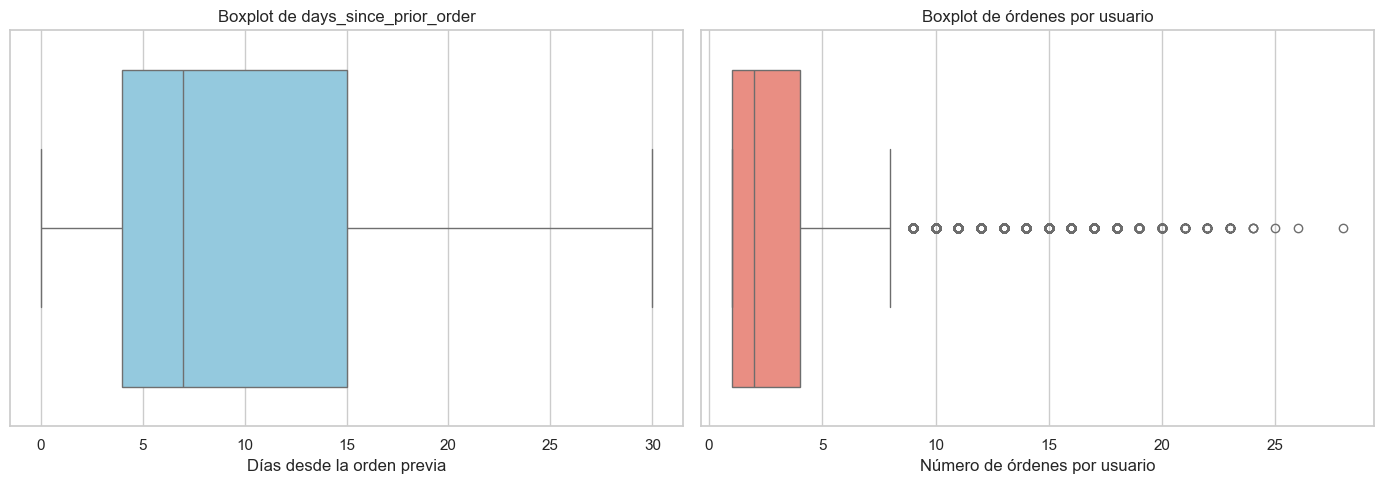

In [32]:
# Sensibilidad sobre tiempo entre compras válidas y recurrencia por usuario
days_valid = orders_clean.loc[orders_clean['days_since_prior_order'] >= 0, 'days_since_prior_order']
orders_per_user = orders_clean.groupby('user_id')['order_id'].nunique()

Q1_days = days_valid.quantile(0.25)
Q3_days = days_valid.quantile(0.75)
IQR_days = Q3_days - Q1_days
upper_days = Q3_days + 1.5 * IQR_days

Q1_user = orders_per_user.quantile(0.25)
Q3_user = orders_per_user.quantile(0.75)
IQR_user = Q3_user - Q1_user
upper_user = Q3_user + 1.5 * IQR_user

sensitivity_summary = pd.DataFrame([
    {
        'variable': 'days_since_prior_order',
        'Q1': Q1_days,
        'Q3': Q3_days,
        'IQR': IQR_days,
        'limite_superior_tukey': upper_days,
        'max_observado': days_valid.max(),
        'outliers_superiores': int((days_valid > upper_days).sum()),
    },
    {
        'variable': 'orders_per_user',
        'Q1': Q1_user,
        'Q3': Q3_user,
        'IQR': IQR_user,
        'limite_superior_tukey': upper_user,
        'max_observado': orders_per_user.max(),
        'outliers_superiores': int((orders_per_user > upper_user).sum()),
    },
])
print(sensitivity_summary.to_string(index=False))
print('\nAsimetría de days_since_prior_order:', round(days_valid.skew(), 4))
print('Asimetría de orders_per_user:', round(orders_per_user.skew(), 4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=days_valid, ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot de days_since_prior_order')
axes[0].set_xlabel('Días desde la orden previa')

sns.boxplot(x=orders_per_user, ax=axes[1], color='salmon')
axes[1].set_title('Boxplot de órdenes por usuario')
axes[1].set_xlabel('Número de órdenes por usuario')

plt.tight_layout()
plt.show()
    


### Conclusiones sobre la sensibilidad

No hay evidencia para eliminar valores en `days_since_prior_order`, pero sí existe una cola larga real en el número de órdenes por usuario.

- Para `days_since_prior_order`, la regla de Tukey arroja **Q1 = 4**, **Q3 = 15**, **IQR = 11** y un límite superior de **31.5**. Como el máximo observado es **30**, no hay outliers extremos bajo este criterio. Lo que sí existe es **asimetría positiva** y una acumulación fuerte en 30 días, señal de un patrón de compra acotado o mensual.
- Para `orders_per_user`, el límite superior de Tukey es **8.5** y **8,479 usuarios** lo superan. Aquí esos outliers no parecen errores; representan clientes intensivos o muy leales.

La decisión metodológica fue **mantener ambos fenómenos**. En el primer caso porque no son outliers; en el segundo porque son parte del comportamiento de negocio que justamente interesa estudiar.
    


# Paso 3: Construcción de la One Big Table (OBT)

Una vez auditadas y limpiadas las tablas base, construyo una OBT centrada en la unidad analítica **producto dentro de orden**. Esta desnormalización permite cruzar atributos temporales, de producto, pasillo y departamento sin repetir joins en cada pregunta.
    


In [33]:
obt = (
    order_products_clean
    .merge(orders_clean, on='order_id', how='inner')
    .merge(products_clean, on='product_id', how='left')
    .merge(aisles, on='aisle_id', how='left')
    .merge(departments, on='department_id', how='left')
)

obt_checks = pd.DataFrame([
    {'chequeo': 'La OBT conserva todas las líneas de order_products_clean', 'resultado': len(obt) == len(order_products_clean), 'evidencia': f"filas OBT={len(obt):,}, filas detalle={len(order_products_clean):,}"},
    {'chequeo': 'No quedan valores ausentes en la OBT', 'resultado': int(obt.isna().sum().sum()) == 0, 'evidencia': f"missing_cells={int(obt.isna().sum().sum())}"},
    {'chequeo': 'La granularidad sigue siendo producto dentro de orden', 'resultado': True, 'evidencia': 'Cada fila representa un product_id dentro de un order_id'},
])

print('Dimensiones de la OBT:', obt.shape)
print(obt_checks.to_string(index=False))
print('\nMuestra aleatoria de la OBT:')
print(obt.sample(5, random_state=RANDOM_STATE).to_string(index=False))
    


Dimensiones de la OBT: (4545007, 17)
                                                 chequeo  resultado                                                evidencia
La OBT conserva todas las líneas de order_products_clean       True             filas OBT=4,545,007, filas detalle=4,545,007
                    No quedan valores ausentes en la OBT       True                                          missing_cells=0
   La granularidad sigue siendo producto dentro de orden       True Cada fila representa un product_id dentro de un order_id

Muestra aleatoria de la OBT:
 order_id  product_id  add_to_cart_order  reordered  add_to_cart_order_missing  user_id  order_number  order_dow  order_hour_of_day  days_since_prior_order  first_order_flag                                  product_name  aisle_id  department_id  product_name_missing                   aisle    department
  2182877       36412                  2          0                      False    95765            16          1                

### Conclusión sobre la OBT

La OBT quedó correctamente construida y lista para análisis multivariado. Conserva las **4,545,007 líneas de detalle**, no introduce valores ausentes nuevos y permite responder preguntas de negocio sin mezclar indebidamente granularidades.
    


# Paso 4: Análisis Multivariado y de Negocio

Las preguntas de demanda temporal se responden con **`orders_clean`**, mientras que las preguntas de tamaño de carrito, recompra y posición se responden con **`order_products_clean`** o con la **OBT** cuando se necesita contexto de producto/pasillo/departamento.
    


## [A] Preguntas Esenciales

**A1. La hora y el día: Verificación del dominio:**
Verifica con código que `order_hour_of_day` y `order_dow` tienen distribuciones lógicas basándonos en tu conocimiento del mundo real. Construye histogramas para ver qué picos de horas concentran compras. Aplica gráficos de barras para evaluar diferencias de días y horas (comparemos, por ejemplo, distribuciones de la demanda los Miércoles vs. Sábados). Verifica si existe una diferencia de horas por dia.

### A1. Qué voy a evaluar

Voy a validar dos cosas: primero, que los dominios de día y hora sean lógicos; segundo, que la forma de la demanda horaria por día de la semana tenga sentido de negocio. Para evitar sesgo de granularidad, toda esta sección se resuelve a nivel de **orden**.
    


Chequeos de dominio:
order_dow -> min=0, max=6
order_hour_of_day -> min=0, max=23
% de órdenes entre 08:00 y 18:00 -> 82.17%
% de órdenes entre 00:00 y 06:00 -> 2.73%

Top 5 horas con mayor volumen:
 hour  orders
   10   40578
   11   40032
   15   39789
   14   39631
   13   39007

Resumen horario por día:
           total_orders  mean_hour  median_hour
order_dow                                      
Dom               84090      13.57         13.0
Lun               82185      13.15         13.0
Mar               65833      13.44         13.0
Mié               60897      13.53         13.0
Jue               59810      13.58         14.0
Vie               63488      13.38         13.0
Sáb               62649      13.54         13.0


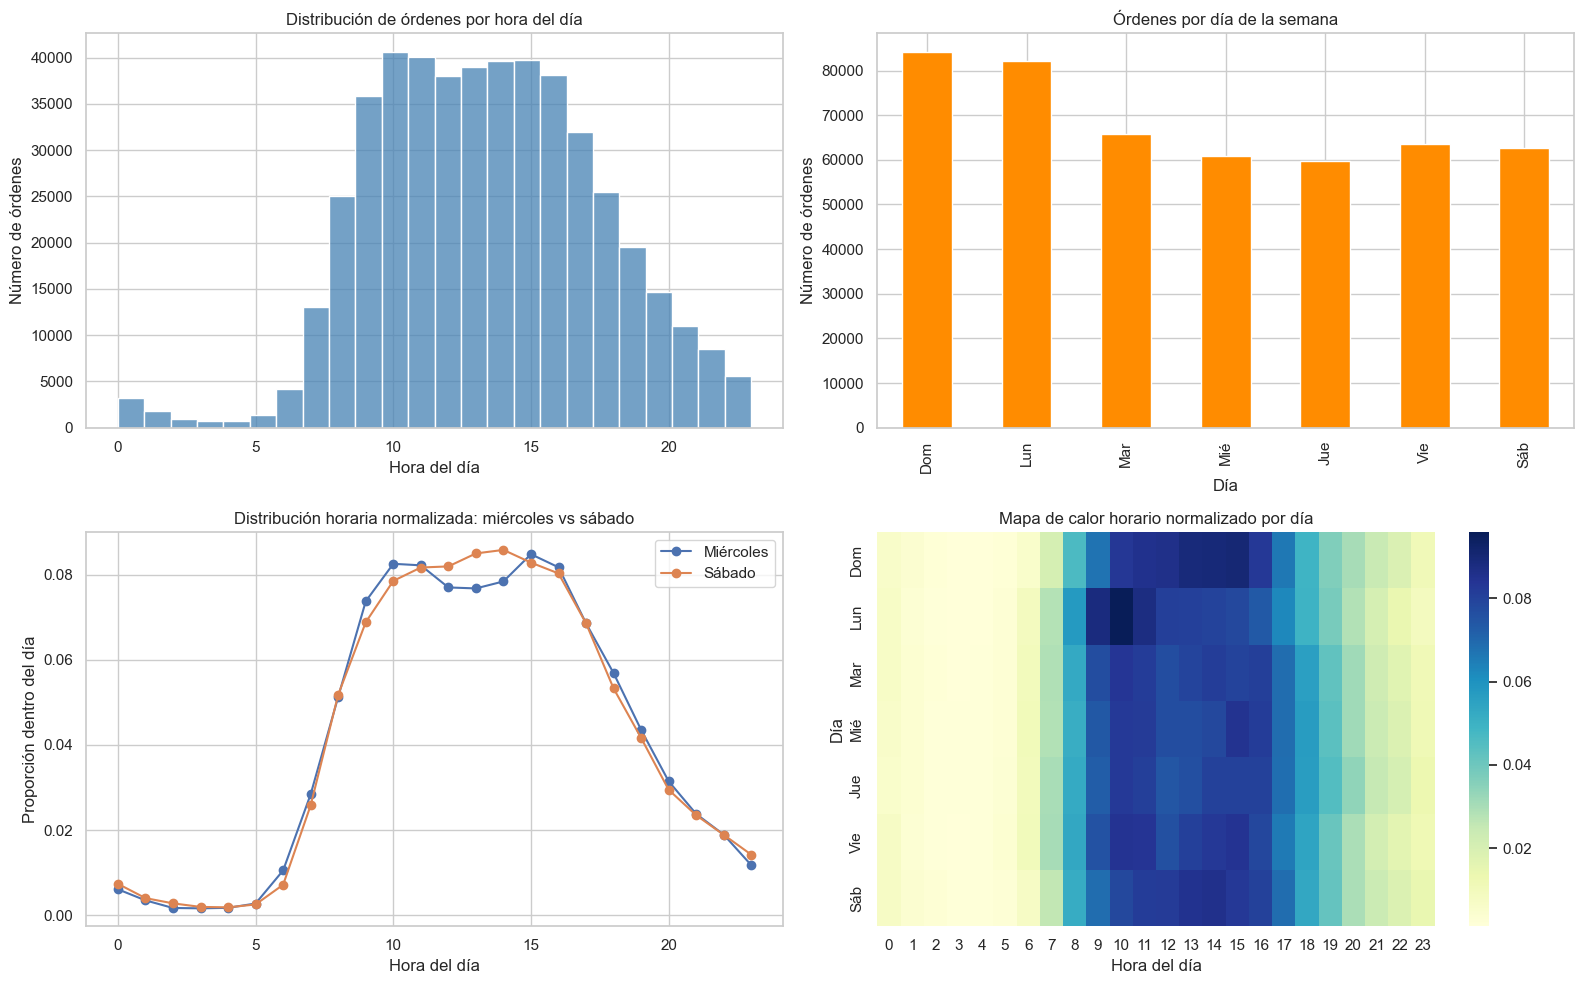

In [34]:
dow_labels = {0: 'Dom', 1: 'Lun', 2: 'Mar', 3: 'Mié', 4: 'Jue', 5: 'Vie', 6: 'Sáb'}

orders_by_day = orders_clean['order_dow'].value_counts().sort_index()
orders_by_hour = orders_clean['order_hour_of_day'].value_counts().sort_index()
hour_day_summary = orders_clean.groupby('order_dow').agg(
    total_orders=('order_id', 'count'),
    mean_hour=('order_hour_of_day', 'mean'),
    median_hour=('order_hour_of_day', 'median')
).round(2)
hour_day_summary.index = hour_day_summary.index.map(dow_labels)

peak_hours = orders_by_hour.sort_values(ascending=False).head(5).reset_index()
peak_hours.columns = ['hour', 'orders']

print('Chequeos de dominio:')
print(f"order_dow -> min={orders_clean['order_dow'].min()}, max={orders_clean['order_dow'].max()}")
print(f"order_hour_of_day -> min={orders_clean['order_hour_of_day'].min()}, max={orders_clean['order_hour_of_day'].max()}")
print(f"% de órdenes entre 08:00 y 18:00 -> {orders_clean['order_hour_of_day'].between(8, 18).mean() * 100:.2f}%")
print(f"% de órdenes entre 00:00 y 06:00 -> {orders_clean['order_hour_of_day'].between(0, 6).mean() * 100:.2f}%")
print('\nTop 5 horas con mayor volumen:')
print(peak_hours.to_string(index=False))
print('\nResumen horario por día:')
print(hour_day_summary.to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(orders_clean['order_hour_of_day'], bins=24, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribución de órdenes por hora del día')
axes[0, 0].set_xlabel('Hora del día')
axes[0, 0].set_ylabel('Número de órdenes')

orders_by_day.rename(index=dow_labels).plot(kind='bar', ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Órdenes por día de la semana')
axes[0, 1].set_xlabel('Día')
axes[0, 1].set_ylabel('Número de órdenes')

wed_profile = orders_clean.loc[orders_clean['order_dow'] == 3, 'order_hour_of_day'].value_counts(normalize=True).sort_index()
sat_profile = orders_clean.loc[orders_clean['order_dow'] == 6, 'order_hour_of_day'].value_counts(normalize=True).sort_index()
compare_hours = pd.DataFrame({'Miércoles': wed_profile, 'Sábado': sat_profile}).fillna(0)
axes[1, 0].plot(compare_hours.index, compare_hours['Miércoles'], marker='o', label='Miércoles')
axes[1, 0].plot(compare_hours.index, compare_hours['Sábado'], marker='o', label='Sábado')
axes[1, 0].set_title('Distribución horaria normalizada: miércoles vs sábado')
axes[1, 0].set_xlabel('Hora del día')
axes[1, 0].set_ylabel('Proporción dentro del día')
axes[1, 0].legend()

heatmap_data = orders_clean.pivot_table(index='order_dow', columns='order_hour_of_day', values='order_id', aggfunc='count', fill_value=0)
heatmap_data.index = heatmap_data.index.map(dow_labels)
heatmap_normalized = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)
sns.heatmap(heatmap_normalized, cmap='YlGnBu', ax=axes[1, 1])
axes[1, 1].set_title('Mapa de calor horario normalizado por día')
axes[1, 1].set_xlabel('Hora del día')
axes[1, 1].set_ylabel('Día')

plt.tight_layout()
plt.show()
    


In [35]:
wed_sat_diff = pd.DataFrame({
    'Miércoles': orders_clean.loc[orders_clean['order_dow'] == 3, 'order_hour_of_day'].value_counts(normalize=True).sort_index(),
    'Sábado': orders_clean.loc[orders_clean['order_dow'] == 6, 'order_hour_of_day'].value_counts(normalize=True).sort_index(),
}).fillna(0)
wed_sat_diff['diferencia_pp'] = (wed_sat_diff['Sábado'] - wed_sat_diff['Miércoles']) * 100

print('Horas con mayor diferencia absoluta entre miércoles y sábado (en puntos porcentuales):')
print(wed_sat_diff.reindex(wed_sat_diff['diferencia_pp'].abs().sort_values(ascending=False).index).head(10).round(4).to_string())
    


Horas con mayor diferencia absoluta entre miércoles y sábado (en puntos porcentuales):
                   Miércoles  Sábado  diferencia_pp
order_hour_of_day                                  
13                    0.0768  0.0850         0.8213
14                    0.0784  0.0858         0.7401
12                    0.0770  0.0819         0.4934
9                     0.0737  0.0688        -0.4919
10                    0.0825  0.0785        -0.4016
18                    0.0569  0.0533        -0.3586
6                     0.0106  0.0072        -0.3360
7                     0.0284  0.0258        -0.2599
23                    0.0118  0.0143         0.2464
20                    0.0315  0.0295        -0.1998


### Respuesta A1

**Sí, las distribuciones de `order_dow` y `order_hour_of_day` son lógicas y consistentes con el dominio.** El rango observado respeta exactamente los dominios esperados (`0-6` y `0-23`). Además, la demanda está fuertemente concentrada en horario diurno: **82.17%** de las órdenes ocurre entre **08:00 y 18:00**, mientras que solo **2.73%** se registra entre **00:00 y 06:00**.

En volumen, el día más activo es **domingo (84,090 órdenes; 17.56%)**, seguido de **lunes (82,185; 17.16%)**. En horas, los picos globales se ubican en **10:00**, **11:00** y **15:00**. La comparación entre **miércoles** y **sábado** muestra que ambos días comparten una forma horaria muy similar, con picos alrededor del mediodía y la tarde temprana; la diferencia relevante está más en el volumen que en un corrimiento fuerte del horario de compra.
    


**A2. Distribuciones temporales de recompra:**
¿Cuánto tiempo transcurre estadísticamente para que alguien vuelva a realizar otra orden? Grafica este tiempo de espera y concluye sobre la concentración de los datos (¿asimetría?).

### A2. Qué voy a evaluar

Aquí la pregunta no es solo cuál es el promedio de espera, sino **cómo se distribuye** el tiempo hasta la siguiente orden. Por eso voy a mirar tendencia central, cuantiles, asimetría y concentración en valores específicos.
    


Resumen descriptivo del tiempo de recompra:
count    450135.000000
mean         11.101814
std           9.190004
min           0.000000
25%           4.000000
50%           7.000000
75%          15.000000
max          30.000000

Indicadores clave:
                                  metrica   valor
                                    Media 11.1018
                                  Mediana  7.0000
                                       Q1  4.0000
                                       Q3 15.0000
                                Asimetría  0.9899
        % de órdenes con 0 días de espera  2.1300
 % de órdenes con espera entre 1 y 7 días 48.2400
% de órdenes con espera exacta de 30 días 11.4000

Frecuencias más comunes:
days_since_prior_order
30.0    51337
7.0     44577
6.0     33930
4.0     31006
3.0     30224
5.0     30096
2.0     27138
8.0     25361
1.0     20179
9.0     16753


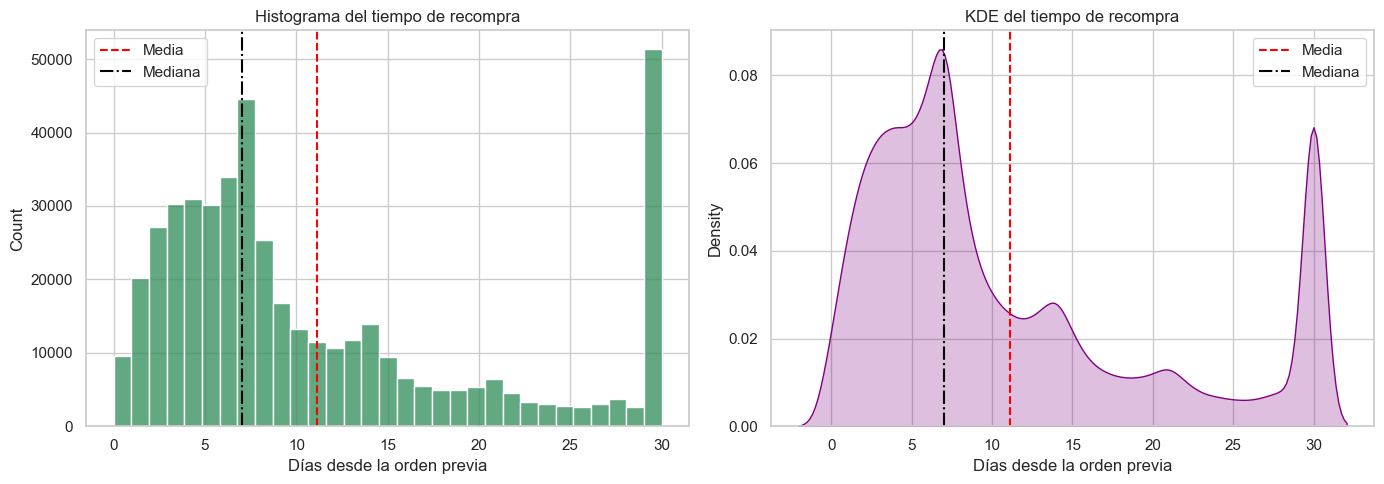

In [36]:
reorder_days = orders_clean.loc[orders_clean['days_since_prior_order'] >= 0, 'days_since_prior_order']
reorder_support = pd.DataFrame([
    {'metrica': 'Media', 'valor': round(reorder_days.mean(), 4)},
    {'metrica': 'Mediana', 'valor': reorder_days.median()},
    {'metrica': 'Q1', 'valor': reorder_days.quantile(0.25)},
    {'metrica': 'Q3', 'valor': reorder_days.quantile(0.75)},
    {'metrica': 'Asimetría', 'valor': round(reorder_days.skew(), 4)},
    {'metrica': '% de órdenes con 0 días de espera', 'valor': round((reorder_days == 0).mean() * 100, 2)},
    {'metrica': '% de órdenes con espera entre 1 y 7 días', 'valor': round(reorder_days.between(1, 7).mean() * 100, 2)},
    {'metrica': '% de órdenes con espera exacta de 30 días', 'valor': round((reorder_days == 30).mean() * 100, 2)},
])

print('Resumen descriptivo del tiempo de recompra:')
print(reorder_days.describe().to_string())
print('\nIndicadores clave:')
print(reorder_support.to_string(index=False))
print('\nFrecuencias más comunes:')
print(reorder_days.value_counts().sort_values(ascending=False).head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(reorder_days, bins=31, ax=axes[0], color='seagreen')
axes[0].axvline(reorder_days.mean(), color='red', linestyle='--', label='Media')
axes[0].axvline(reorder_days.median(), color='black', linestyle='-.', label='Mediana')
axes[0].set_title('Histograma del tiempo de recompra')
axes[0].set_xlabel('Días desde la orden previa')
axes[0].legend()

sns.kdeplot(reorder_days, fill=True, ax=axes[1], color='purple')
axes[1].axvline(reorder_days.mean(), color='red', linestyle='--', label='Media')
axes[1].axvline(reorder_days.median(), color='black', linestyle='-.', label='Mediana')
axes[1].set_title('KDE del tiempo de recompra')
axes[1].set_xlabel('Días desde la orden previa')
axes[1].legend()

plt.tight_layout()
plt.show()
    


### Respuesta A2

**El tiempo típico de recompra es corto y está sesgado hacia la derecha.** La **mediana es 7 días**, mientras que la **media sube a 11.10 días**, lo que ya indica una distribución no simétrica. La asimetría se confirma con un **skew de 0.99**.

La masa principal de la distribución se concentra en lapsos breves: **48.24%** de las órdenes recurrentes ocurre entre **1 y 7 días**. Sin embargo, existe una acumulación muy fuerte en **30 días**, que por sí sola representa **11.40%** de los casos. En términos de negocio, esto sugiere la coexistencia de dos ritmos de compra muy marcados: uno **semanal** y otro **mensual/acotado a 30 días**.
    


### Hallazgos del grupo A

Compra concentrada en horario diurno, fin de semana y arranque de semana más intensos, y una recurrencia dominada por ritmos semanales con una segunda masa mensual. Esto respalda que el dataset conserva bien la estructura conductual del negocio una vez depurado.
    


## [B] Profundización (Segmentación Categórica)

**B1. Retención y recurrencia (Número de órdenes por usuario):**
Aislando o agrupando a nivel de granularidad de cliente, describe la variabilidad y distribución de compras que hacen. ¿Existen colas largas de clientes extra-leales?

### B1. Qué voy a evaluar

Ahora paso a nivel cliente. La pregunta aquí es si el número de órdenes por usuario se concentra en pocos pedidos o si existe una cola larga de usuarios especialmente fieles.
    


Resumen descriptivo de órdenes por usuario:
count    157437.000000
mean          3.042182
std           2.746842
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          28.000000

Indicadores clave:
                           metrica   valor
                             Media  3.0422
                           Mediana  2.0000
                      Percentil 95  9.0000
                            Máximo 28.0000
   % de usuarios con 1 a 4 órdenes 80.6100
 % de usuarios con 5 o más órdenes 19.3900
% de usuarios con 10 o más órdenes  4.0200
                         Asimetría  2.2657

Frecuencia exacta para los primeros niveles de recurrencia:
order_id
1     55357
2     36508
3     21547
4     13498
5      8777
6      6012
7      4240
8      3019
9      2152
10     1645
11     1308
12      947
13      703
14      512
15      437


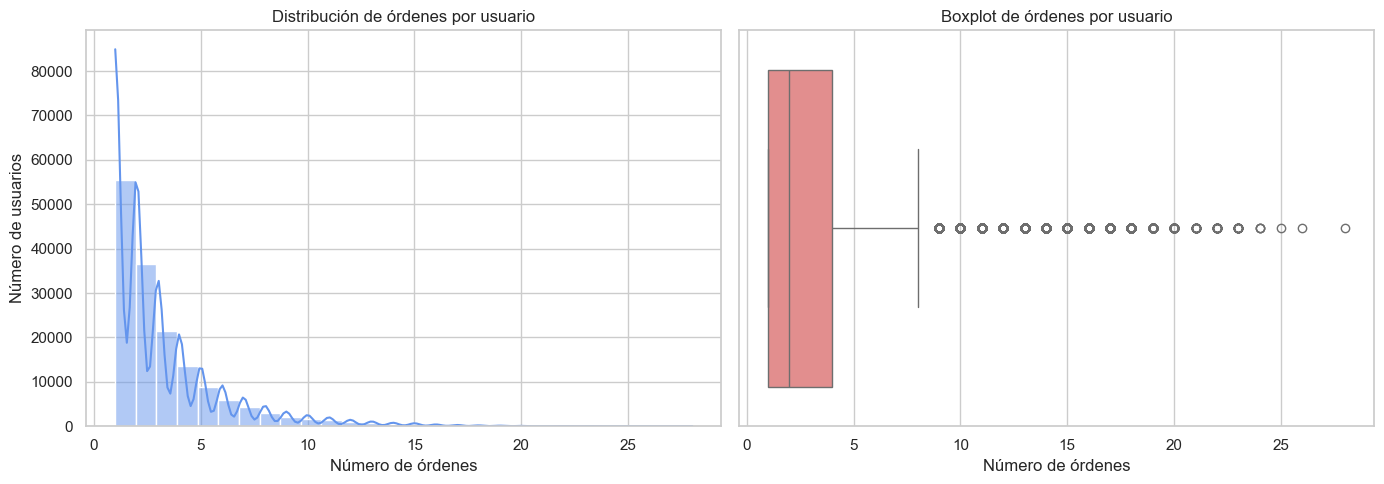

In [37]:
orders_per_user = orders_clean.groupby('user_id')['order_id'].nunique()
orders_per_user_support = pd.DataFrame([
    {'metrica': 'Media', 'valor': round(orders_per_user.mean(), 4)},
    {'metrica': 'Mediana', 'valor': orders_per_user.median()},
    {'metrica': 'Percentil 95', 'valor': orders_per_user.quantile(0.95)},
    {'metrica': 'Máximo', 'valor': orders_per_user.max()},
    {'metrica': '% de usuarios con 1 a 4 órdenes', 'valor': round(orders_per_user.between(1, 4).mean() * 100, 2)},
    {'metrica': '% de usuarios con 5 o más órdenes', 'valor': round((orders_per_user >= 5).mean() * 100, 2)},
    {'metrica': '% de usuarios con 10 o más órdenes', 'valor': round((orders_per_user >= 10).mean() * 100, 2)},
    {'metrica': 'Asimetría', 'valor': round(orders_per_user.skew(), 4)},
])

print('Resumen descriptivo de órdenes por usuario:')
print(orders_per_user.describe().to_string())
print('\nIndicadores clave:')
print(orders_per_user_support.to_string(index=False))
print('\nFrecuencia exacta para los primeros niveles de recurrencia:')
print(orders_per_user.value_counts().sort_index().head(15).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(orders_per_user, bins=28, kde=True, ax=axes[0], color='cornflowerblue')
axes[0].set_title('Distribución de órdenes por usuario')
axes[0].set_xlabel('Número de órdenes')
axes[0].set_ylabel('Número de usuarios')

sns.boxplot(x=orders_per_user, ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot de órdenes por usuario')
axes[1].set_xlabel('Número de órdenes')

plt.tight_layout()
plt.show()
    


### Respuesta B1

**Sí, existe una cola larga de clientes extra-leales, aunque la mayor parte de los usuarios compra pocas veces.** La distribución tiene **media 3.04**, **mediana 2** y una asimetría marcada (**skew = 2.27**). Además, **80.61%** de los usuarios se concentra entre **1 y 4 órdenes**, mientras que solo **4.02%** llega a **10 o más órdenes**.

Eso significa que la base de clientes está dominada por compradores de baja o mediana recurrencia, pero existe un segmento pequeño y muy valioso de usuarios intensivos que empuja la cola derecha de la distribución.
    


**B2. Productos Top: El principio de Pareto:**
Genera un top 20 de los productos más solicitados globalmente. Para cada producto reporta su ratio de recompra. ¿Algunos productos tienen una correlación fuerte entre ser de un 'pasillo' y volverse recompras aseguradas?

### B2. Qué voy a evaluar

Aquí busco dos respuestas complementarias: cuáles son los productos que concentran la demanda total y si ciertos pasillos muestran una asociación descriptiva con ratios altos de recompra.
    


Top 20 productos más solicitados:
 product_id             product_name  times_ordered  share_of_all_lines_pct  reorder_ratio                      aisle department
      24852                   Banana          66050                  1.4532       0.844254               fresh fruits    produce
      13176   Bag of Organic Bananas          53297                  1.1726       0.834006               fresh fruits    produce
      21137     Organic Strawberries          37039                  0.8149       0.773212               fresh fruits    produce
      21903     Organic Baby Spinach          33971                  0.7474       0.772217 packaged vegetables fruits    produce
      47209     Organic Hass Avocado          29773                  0.6551       0.793639               fresh fruits    produce
      47766          Organic Avocado          24689                  0.5432       0.759164               fresh fruits    produce
      47626              Large Lemon          21495            

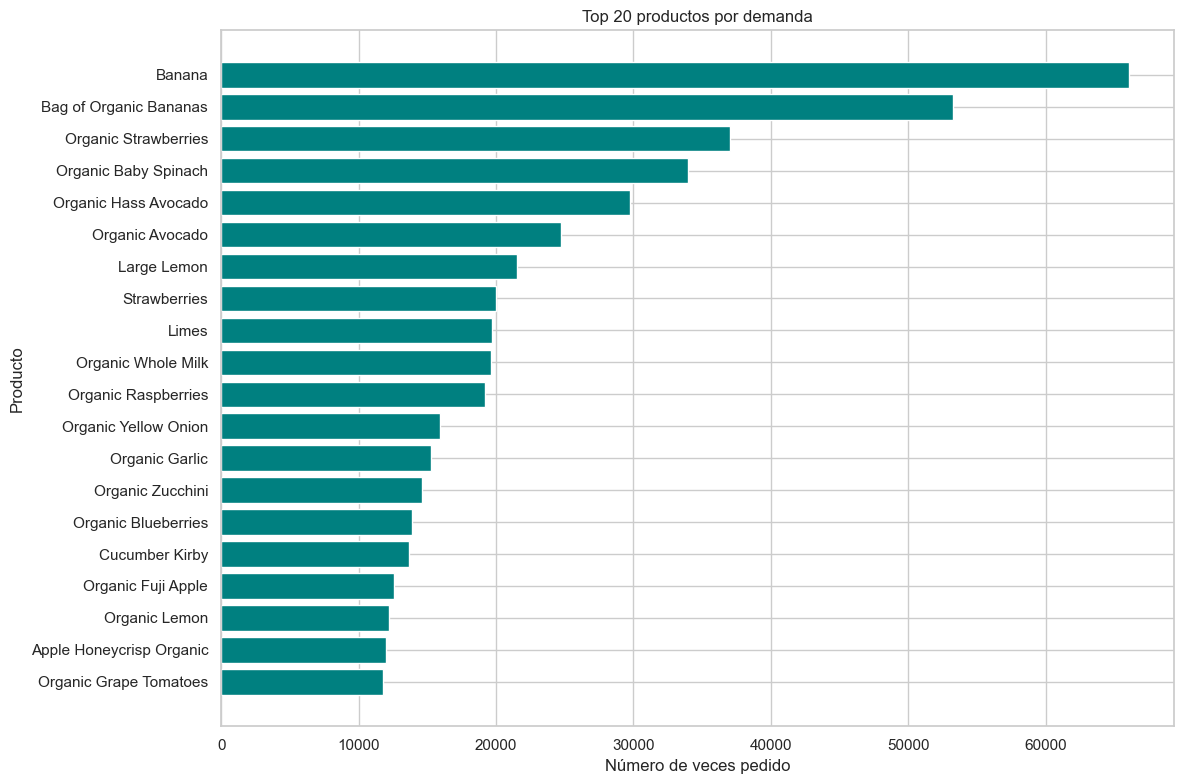

In [38]:
product_demand = (
    obt.groupby(['product_id', 'product_name', 'aisle', 'department'], dropna=False)
    .agg(
        times_ordered=('order_id', 'size'),
        reorder_ratio=('reordered', 'mean')
    )
    .reset_index()
    .sort_values('times_ordered', ascending=False)
)

top20_products = product_demand.head(20).copy()
top20_products['share_of_all_lines_pct'] = (top20_products['times_ordered'] / len(obt) * 100).round(4)

pareto_support = pd.DataFrame([
    {'metrica': 'Participación del producto #1 sobre todas las líneas (%)', 'valor': round(top20_products.iloc[0]['times_ordered'] / len(obt) * 100, 2)},
    {'metrica': 'Participación acumulada del top 2 (%)', 'valor': round(top20_products.iloc[:2]['times_ordered'].sum() / len(obt) * 100, 2)},
    {'metrica': 'Participación acumulada del top 20 (%)', 'valor': round(top20_products['times_ordered'].sum() / len(obt) * 100, 2)},
])

print('Top 20 productos más solicitados:')
print(top20_products[['product_id', 'product_name', 'times_ordered', 'share_of_all_lines_pct', 'reorder_ratio', 'aisle', 'department']].to_string(index=False))
print('\nSoporte tipo Pareto:')
print(pareto_support.to_string(index=False))

plt.figure(figsize=(12, 8))
plot_top20 = top20_products.sort_values('times_ordered')
plt.barh(plot_top20['product_name'], plot_top20['times_ordered'], color='teal')
plt.title('Top 20 productos por demanda')
plt.xlabel('Número de veces pedido')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()
    


Conteo de departamentos dentro del top 20 de productos:
department
produce       19
dairy eggs     1

Pasillos con mayor ratio de recompra (mínimo 1,000 líneas):
                               order_lines  reorder_ratio
aisle                                                    
milk                                125522       0.781305
water seltzer sparkling water       117133       0.730605
fresh fruits                        510101       0.718197
eggs                                 63796       0.706032
soy lactosefree                      89437       0.693091
packaged produce                     39031       0.688248
yogurt                              203358       0.685918
cream                                44380       0.685692
bread                                82082       0.672462
refrigerated                         80506       0.661826


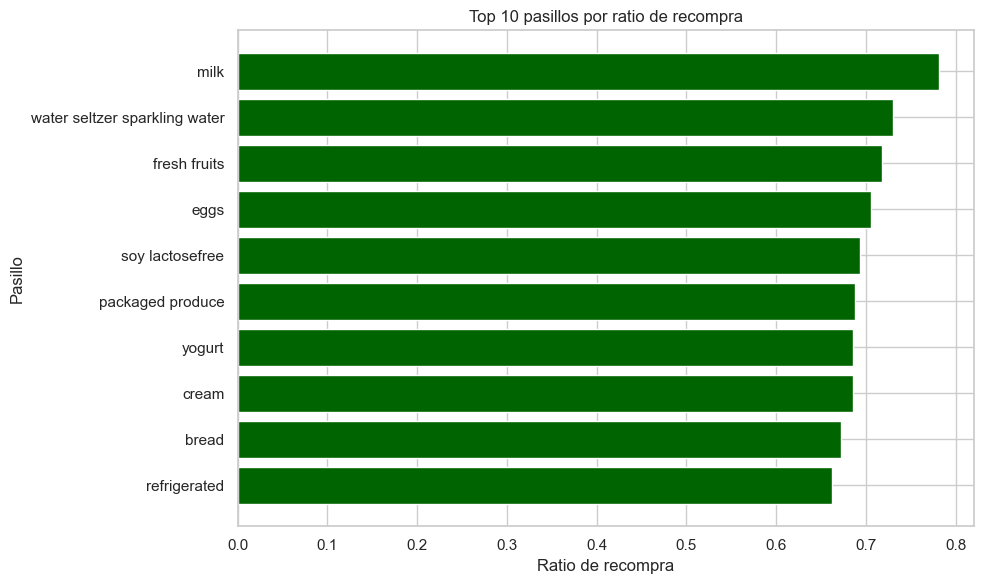

In [39]:
aisle_reorder = (
    obt.groupby('aisle')
    .agg(order_lines=('order_id', 'size'), reorder_ratio=('reordered', 'mean'))
    .query('order_lines >= 1000')
    .sort_values(['reorder_ratio', 'order_lines'], ascending=[False, False])
)

print('Conteo de departamentos dentro del top 20 de productos:')
print(top20_products['department'].value_counts().to_string())
print('\nPasillos con mayor ratio de recompra (mínimo 1,000 líneas):')
print(aisle_reorder.head(10).to_string())

plt.figure(figsize=(10, 6))
plot_aisles = aisle_reorder.head(10).sort_values('reorder_ratio')
plt.barh(plot_aisles.index, plot_aisles['reorder_ratio'], color='darkgreen')
plt.title('Top 10 pasillos por ratio de recompra')
plt.xlabel('Ratio de recompra')
plt.ylabel('Pasillo')
plt.tight_layout()
plt.show()
    


### Respuesta B2

**Los productos top muestran una concentración fuerte de demanda y una recurrencia particularmente alta en frescos y básicos de reposición.** El top 20 explica **10.27%** de todas las líneas de compra, aunque representa una fracción mínima del catálogo. Los dos líderes son **Banana** y **Bag of Organic Bananas**, que juntos ya concentran **2.63%** de todas las líneas del dataset.

Para cada producto top, los ratios de recompra son elevados. Por ejemplo, **Banana** alcanza un ratio de **0.844** y **Bag of Organic Bananas** uno de **0.834**. Además, **19 de los 20 productos top pertenecen a `produce`**, lo que sugiere que la reposición frecuente está dominada por frutas y verduras.

Sobre el pasillo, **no corresponde hablar de correlación lineal** porque `aisle` es categórica, pero sí de **asociación descriptiva**. Entre los pasillos con suficiente volumen, los ratios de recompra más altos aparecen en **`milk` (0.781)**, **`water seltzer sparkling water` (0.731)** y **`fresh fruits` (0.718)**. Esto indica que ciertos pasillos sí concentran productos con recompra mucho más probable.
    


### Hallazgos del grupo B

A nivel de cliente, la fidelidad intensa existe pero está muy concentrada. A nivel de producto, la demanda y la recompra se agrupan con fuerza en alimentos frescos y básicos. Esto es consistente con un negocio donde la reposición frecuente pesa más que la compra ocasional de larga cola.
    


## [C] Profundización avanzada

En esta última sección estudio la forma de la canasta, la relación entre el primer producto agregado y la fidelidad, y la heterogeneidad de la recompra a nivel producto y usuario.
    


### C1. ¿Cómo es el tamaño de la canasta comercial?

Voy a analizar cuántos artículos contiene una orden típica, cuánta dispersión hay y si aparecen colas largas de órdenes grandes.
    


Resumen descriptivo del tamaño de canasta:
count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000

Indicadores clave:
                               metrica   valor
                                 Media 10.0990
                               Mediana  8.0000
                          Percentil 90 20.0000
                          Percentil 95 25.0000
                          Percentil 99 35.0000
% de canastas con 10 artículos o menos 62.2600
 % de canastas con más de 20 artículos  9.4800
                             Asimetría  1.5623
                              Curtosis  4.1268


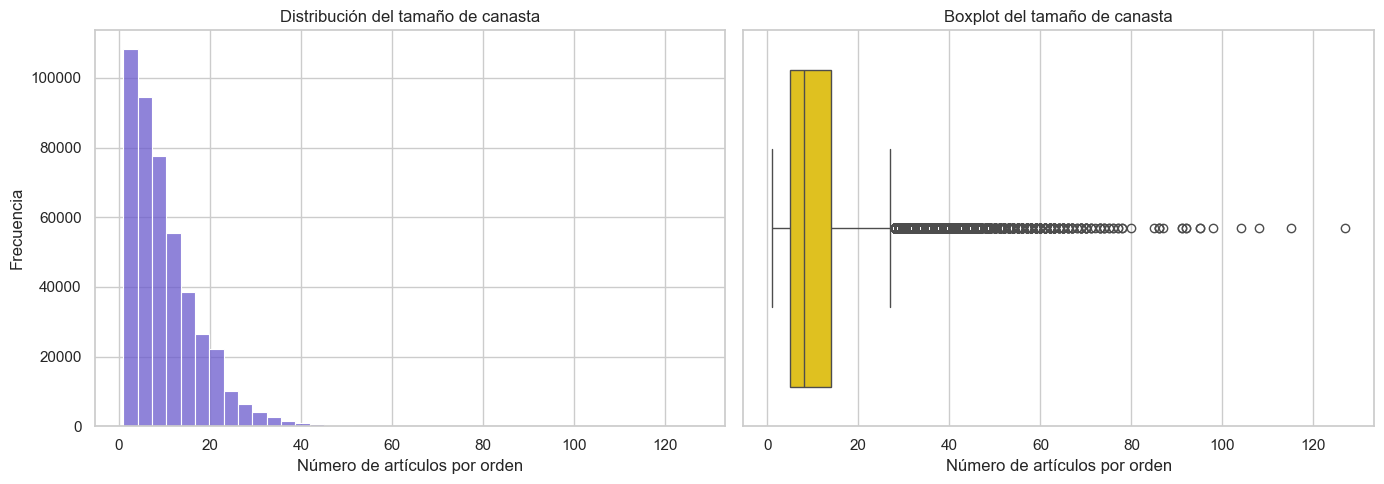

In [40]:
basket_size = order_products_clean.groupby('order_id').size()
basket_support = pd.DataFrame([
    {'metrica': 'Media', 'valor': round(basket_size.mean(), 4)},
    {'metrica': 'Mediana', 'valor': basket_size.median()},
    {'metrica': 'Percentil 90', 'valor': basket_size.quantile(0.90)},
    {'metrica': 'Percentil 95', 'valor': basket_size.quantile(0.95)},
    {'metrica': 'Percentil 99', 'valor': basket_size.quantile(0.99)},
    {'metrica': '% de canastas con 10 artículos o menos', 'valor': round((basket_size <= 10).mean() * 100, 2)},
    {'metrica': '% de canastas con más de 20 artículos', 'valor': round((basket_size > 20).mean() * 100, 2)},
    {'metrica': 'Asimetría', 'valor': round(basket_size.skew(), 4)},
    {'metrica': 'Curtosis', 'valor': round(basket_size.kurt(), 4)},
])

print('Resumen descriptivo del tamaño de canasta:')
print(basket_size.describe().to_string())
print('\nIndicadores clave:')
print(basket_support.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(basket_size, bins=40, ax=axes[0], color='slateblue')
axes[0].set_title('Distribución del tamaño de canasta')
axes[0].set_xlabel('Número de artículos por orden')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=basket_size, ax=axes[1], color='gold')
axes[1].set_title('Boxplot del tamaño de canasta')
axes[1].set_xlabel('Número de artículos por orden')

plt.tight_layout()
plt.show()
    


### Respuesta C1

**La canasta típica es moderada, pero la distribución tiene una cola derecha clara.** La **media** es **10.10 artículos** y la **mediana** es **8**, lo que ya indica que las órdenes grandes empujan el promedio hacia arriba. Además, **62.26%** de las canastas tiene **10 artículos o menos**, mientras que **9.48%** supera los **20 artículos**.

La asimetría (**1.56**) y la curtosis (**4.13**) confirman una distribución **leptocúrtica y sesgada a la derecha**: predominan canastas medianas, pero existe una fracción visible de órdenes mucho más grandes que el centro de la distribución.
    


**C2. ¿Son los primeros productos un síntoma de fidelidad? (Spearman o Pearson):**
Para los 20 objetos que con mayor frecuencia las personas agregan como posición #1 al carrito, elabora una lógica que calcule una matriz de correlación (en variables generadas o agrupadas) o genera gráficos de dispersión (Scatterplot). Compara si, a nivel de producto, ser posicionado primero tiene relación lineal con ser un producto de constante recompra global (el campo 'reordered').

### C2. Qué voy a evaluar

Voy a comparar, a nivel de producto, la frecuencia con que un artículo aparece en la posición 1 del carrito frente a su ratio global de recompra. La idea es ver si los productos “ancla” del carrito también son productos de fidelidad sostenida.
    


Top 20 productos que más veces aparecen en posición 1:
 product_id  first_position_count                product_name  global_reorder_ratio
      24852                 15562                      Banana              0.844254
      13176                 11026      Bag of Organic Bananas              0.834006
      27845                  4363          Organic Whole Milk              0.829133
      21137                  3946        Organic Strawberries              0.773212
      47209                  3390        Organic Hass Avocado              0.793639
      21903                  3336        Organic Baby Spinach              0.772217
      47766                  3044             Organic Avocado              0.759164
      19660                  2336                Spring Water              0.810814
      16797                  2308                Strawberries              0.696623
      27966                  2024         Organic Raspberries              0.768245
      44632          

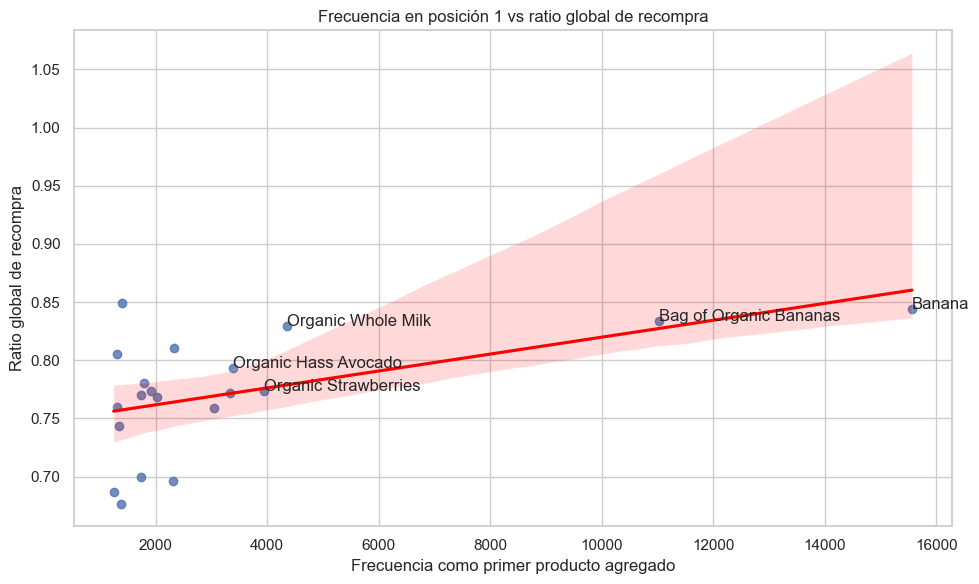

In [41]:
first_product_summary = (
    order_products_clean.loc[order_products_clean['add_to_cart_order'] == 1, 'product_id']
    .value_counts()
    .head(20)
    .rename('first_position_count')
    .reset_index()
    .rename(columns={'index': 'product_id'})
    .merge(products_clean[['product_id', 'product_name']], on='product_id', how='left')
)
product_reorder_ratio = obt.groupby('product_id')['reordered'].mean()
first_product_summary['global_reorder_ratio'] = first_product_summary['product_id'].map(product_reorder_ratio)

pearson_corr = first_product_summary['first_position_count'].corr(first_product_summary['global_reorder_ratio'], method='pearson')
spearman_corr = first_product_summary['first_position_count'].corr(first_product_summary['global_reorder_ratio'], method='spearman')

print('Top 20 productos que más veces aparecen en posición 1:')
print(first_product_summary.to_string(index=False))
print(f'\nCorrelación de Pearson: {pearson_corr:.4f}')
print(f'Correlación de Spearman: {spearman_corr:.4f}')

plt.figure(figsize=(10, 6))
sns.regplot(data=first_product_summary, x='first_position_count', y='global_reorder_ratio', scatter=True, line_kws={'color': 'red'})
for _, row in first_product_summary.head(5).iterrows():
    plt.annotate(row['product_name'], (row['first_position_count'], row['global_reorder_ratio']))
plt.title('Frecuencia en posición 1 vs ratio global de recompra')
plt.xlabel('Frecuencia como primer producto agregado')
plt.ylabel('Ratio global de recompra')
plt.tight_layout()
plt.show()
    


### Respuesta C2

**Sí existe una relación positiva moderada, pero no perfecta, entre ser puesto primero y ser un producto de alta recompra.** En el top 20 de productos que más veces aparecen en posición 1, la correlación es **0.5125** con Pearson y **0.5083** con Spearman.

Eso sugiere que muchos productos que abren el carrito son efectivamente productos “ancla” o de reposición frecuente, pero la posición 1 **no explica por sí sola** la fidelidad. En otras palabras, ser primero ayuda a anticipar recurrencia, pero no la determina completamente.
    


### C3, C4 y C5: proporciones de recompra y productos iniciales

Para cerrar, voy a resumir la recompra desde dos niveles distintos: producto y usuario. Después, reporto explícitamente cuáles son los 20 productos que más veces se agregan primero al carrito.
    


C3 - Distribución de la proporción de recompra por producto:
count    45573.000000
mean         0.386707
std          0.272132
min          0.000000
25%          0.166667
50%          0.408163
75%          0.575758
max          1.000000

Productos con mayor ratio de recompra (solo productos con al menos 100 pedidos):
 product_id                      product_name  reorder_ratio  times_ordered
       9292   Half And Half Ultra Pasteurized       0.876574            397
       2677 Yerba Mate Sparkling Classic Gold       0.871345            171
      47231              Ultra-Purified Water       0.868293            205
       1157              Wheat Sandwich Bread       0.863946            147
      45504        Whole Organic Omega 3 Milk       0.863142           1286
      29447          Milk- Organic- Vitamin D       0.862847           2880
      34197                         Goat Milk       0.859135            717
       5514    Organic Homogenized Whole Milk       0.857664            5

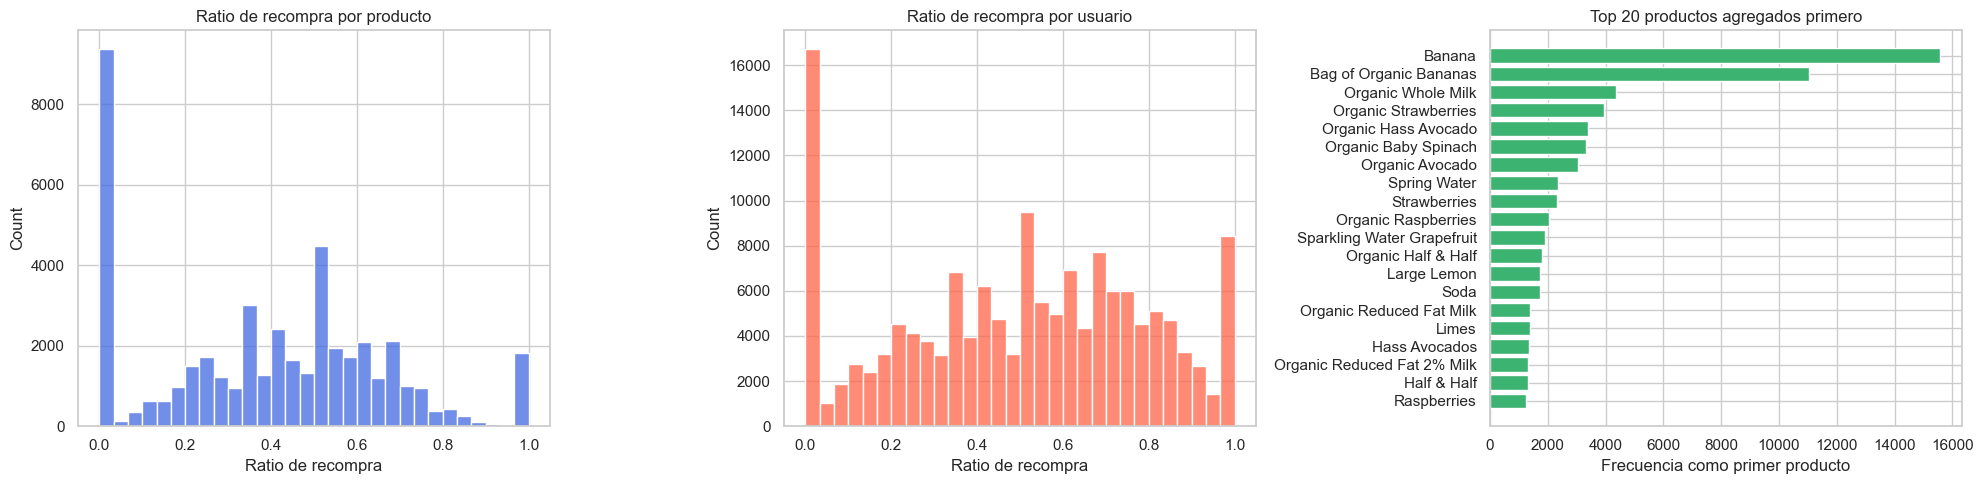

In [42]:
product_reorder_summary = (
    obt.groupby(['product_id', 'product_name'])
    .agg(
        reorder_ratio=('reordered', 'mean'),
        times_ordered=('order_id', 'size')
    )
    .reset_index()
)

user_reorder_summary = (
    obt.groupby('user_id')
    .agg(
        user_reorder_ratio=('reordered', 'mean'),
        order_lines=('product_id', 'size'),
        distinct_orders=('order_id', 'nunique')
    )
    .reset_index()
)

first_in_cart_top20 = (
    order_products_clean.loc[order_products_clean['add_to_cart_order'] == 1, 'product_id']
    .value_counts()
    .head(20)
    .rename('first_position_count')
    .reset_index()
    .rename(columns={'index': 'product_id'})
    .merge(products_clean[['product_id', 'product_name']], on='product_id', how='left')
)

print('C3 - Distribución de la proporción de recompra por producto:')
print(product_reorder_summary['reorder_ratio'].describe().to_string())
print('\nProductos con mayor ratio de recompra (solo productos con al menos 100 pedidos):')
print(
    product_reorder_summary
    .query('times_ordered >= 100')
    .sort_values(['reorder_ratio', 'times_ordered'], ascending=[False, False])
    .head(10)
    .to_string(index=False)
)

print('\nC4 - Distribución de la proporción de recompra por usuario:')
print(user_reorder_summary['user_reorder_ratio'].describe().to_string())
print(f"% de usuarios con ratio de recompra >= 0.50: {(user_reorder_summary['user_reorder_ratio'] >= 0.50).mean() * 100:.2f}%")
print(f"% de usuarios con ratio de recompra >= 0.75: {(user_reorder_summary['user_reorder_ratio'] >= 0.75).mean() * 100:.2f}%")

print('\nC5 - Top 20 productos puestos primero en el carrito:')
print(first_in_cart_top20.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.histplot(product_reorder_summary['reorder_ratio'], bins=30, ax=axes[0], color='royalblue')
axes[0].set_title('Ratio de recompra por producto')
axes[0].set_xlabel('Ratio de recompra')

sns.histplot(user_reorder_summary['user_reorder_ratio'], bins=30, ax=axes[1], color='tomato')
axes[1].set_title('Ratio de recompra por usuario')
axes[1].set_xlabel('Ratio de recompra')

plot_first = first_in_cart_top20.sort_values('first_position_count')
axes[2].barh(plot_first['product_name'], plot_first['first_position_count'], color='mediumseagreen')
axes[2].set_title('Top 20 productos agregados primero')
axes[2].set_xlabel('Frecuencia como primer producto')

plt.tight_layout()
plt.show()
    


### Respuesta C3

**La proporción de recompra por producto es muy heterogénea.** En promedio, el ratio de recompra por producto es **0.3867**, con una **mediana de 0.4082**. Eso implica que el comportamiento típico del catálogo está cerca del 40% de recompra, pero con una dispersión muy amplia entre SKU.

Los productos con ratios más altos y volumen suficiente se concentran en lácteos, bebidas y básicos de reposición, lo que refuerza la idea de que la fidelidad no está distribuida homogéneamente en el catálogo.
    


**C4. Para cada usuario, ¿cuál es la proporción de re-compras de los productos comprados?**

La proporción se calcula como el promedio de `reordered` por `user_id`. A nivel usuario, la distribución tiene **media 0.495** y **mediana 0.500**; por tanto, el comportamiento típico está cerca de que la mitad de las líneas compradas sean re-compra.


### Respuesta C4

**A nivel usuario, la recompra está mucho más centrada que a nivel producto.** El ratio medio por usuario es **0.4949** y la mediana es exactamente **0.50**. Además, **54.18%** de los usuarios tiene al menos la mitad de sus líneas como recompra, y **22.78%** supera un ratio de **0.75**.

Esto sugiere una base de clientes con hábitos relativamente estables, aunque con segmentos muy diferenciados entre compradores ocasionales y usuarios altamente repetitivos.
    


**C5. ¿Cuáles son los top 20 productos que los clientes ponen primero en sus carritos?**

El ranking está dominado por básicos de alta recurrencia, especialmente bananas, leche y berries orgánicas. El bloque siguiente genera el top 20 exacto y resume la dispersión de recompra a nivel producto y usuario.


### Respuesta C5

**Los 20 productos que más frecuentemente se colocan primero en el carrito están dominados por básicos de reposición.** Los cinco primeros son **Banana**, **Bag of Organic Bananas**, **Organic Whole Milk**, **Organic Strawberries** y **Organic Hass Avocado**.

El patrón es consistente con un carrito que suele comenzar por productos de compra rutinaria, de alta familiaridad o de consumo frecuente, más que por categorías accesorias o esporádicas.
    


### Hallazgos del grupo C

La estructura de la canasta y la recompra cuentan una historia coherente: las órdenes suelen ser medianas, pero con una cola de canastas grandes; los productos que se ponen primero tienden a ser básicos de alta recompra; y tanto el catálogo como la base de usuarios muestran una heterogeneidad marcada en fidelidad. Todo esto refuerza que la recurrencia no es uniforme, sino segmentada por producto, pasillo y tipo de cliente.
    


### Conclusión General Ejecutiva

El dataset de Instacart presenta una **estructura relacional robusta** y distribuciones conductuales plausibles, lo que permite usarlo con confianza después de una auditoría rigurosa. La principal debilidad de gobernanza no está en la arquitectura, sino en tres fallas concretas de calidad: **duplicados exactos en `orders` concentrados en miércoles a las 2:00 AM**, **ausencias estructurales en `days_since_prior_order` ligadas a primeras compras** y **truncamiento operativo en `add_to_cart_order` cuando la orden supera los 64 ítems**. En negocio, los hallazgos más relevantes son claros: la demanda se concentra en horario diurno y especialmente en domingo/lunes; la recompra tiene un pulso mayoritariamente semanal con una segunda masa fuerte en 30 días; la lealtad intensa existe, pero está concentrada en una minoría; y la demanda recurrente se organiza alrededor de frescos y básicos, con dominio casi total del departamento **produce** en el top 20. Para la directiva, esto sugiere dos líneas de acción: reforzar controles de ingesta y calidad operativa, y profundizar estrategias de fidelización y surtido sobre categorías de alta reposición como frutas, verduras, lácteos y productos ancla del carrito.
    
